In [62]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from tslearn.metrics import cdist_dtw
from helper_plots import plot_pseudotime_for_cells
from pathlib import Path

def sample_rows_per_cluster(df, cluster_col, n=5, random_state=42):
    return (
        df
        .groupby(cluster_col, group_keys=False)
        .apply(lambda x: x.sample(min(n, len(x)), random_state=random_state))
    )


def compute_mean_std(ts_list):
    ts_list = [np.asarray(ts, dtype=float) for ts in ts_list]
    max_len = max(len(ts) for ts in ts_list)
    aligned = [
        np.pad(ts, (0, max_len - len(ts)), constant_values=np.nan)
        for ts in ts_list
    ]
    mat = np.vstack(aligned)
    return np.nanmean(mat, axis=0), np.nanstd(mat, axis=0)

def plot_kmeans_mean_shapes(X, labels):
    plt.figure(figsize=(12,6))

    for lab in sorted(set(labels)):
        idx = np.where(labels == lab)[0]
        ts_list = [X[i] for i in idx]

        mean_ts, std_ts = compute_mean_std(ts_list)
        t = np.arange(len(mean_ts))

        plt.plot(t, mean_ts, label=f"Cluster {lab}", linewidth=2)
        plt.fill_between(t, mean_ts - std_ts, mean_ts + std_ts, alpha=0.2)

    plt.title("KMeans Mean Shape per Cluster (± STD)")
    plt.legend()
    plt.show()

In [63]:

SD_clean = pd.read_pickle("checkpoints/pseudotime_cells_clean_1462.pkl")

n = 6  # minimum required length

SD_clean = SD_clean[SD_clean["pseudotime_widths"].apply(len) >= n]


outliers = []
with open(r"datasets\1462_dapi_python_segmentation_outliers.txt", "r") as f:
    for line in f:
        outliers.append(line.strip() +".tif")

print(outliers)

SD_clean = SD_clean[
    ~SD_clean["path_dapi"].apply(lambda p: Path(p).name).isin(outliers)
]


#X = SD_clean["pseudotime_widths"].to_list()

SD_clean

['obj6020001_stainDAPI.tif', 'obj6130001_stainDAPI.tif', 'obj6130004_stainDAPI.tif', 'obj6360001_stainDAPI.tif', 'obj6460002_stainDAPI.tif', 'obj6470001_stainDAPI.tif', 'obj6640001_stainDAPI.tif', 'obj6640002_stainDAPI.tif', 'obj6760002_stainDAPI.tif', 'obj7000001_stainDAPI.tif', 'obj2690001_stainDAPI.tif', 'obj2840001_stainDAPI.tif', 'obj2990015_stainDAPI.tif', 'obj2990024_stainDAPI.tif', 'obj2990036_stainDAPI.tif', 'obj2990041_stainDAPI.tif', 'obj3370001_stainDAPI.tif', 'obj3370002_stainDAPI.tif', 'obj3370003_stainDAPI.tif', 'obj4570003_stainDAPI.tif', 'obj4650001_stainDAPI.tif', 'obj4700002_stainDAPI.tif', 'obj4750001_stainDAPI.tif', 'obj4920001_stainDAPI.tif', 'obj4970001_stainDAPI.tif', 'obj4980001_stainDAPI.tif', 'obj4980002_stainDAPI.tif', 'obj5210002_stainDAPI.tif', 'obj5210003_stainDAPI.tif', 'obj5420001_stainDAPI.tif', 'obj130002_stainDAPI.tif', 'obj220001_stainDAPI.tif', 'obj1370002_stainDAPI.tif', 'obj2010001_stainDAPI.tif', 'obj2500001_stainDAPI.tif', 'obj49800010002_stain

,path_background,path_dapi,path_yap,path_actin,height,width,channels,radial_distribution.RadialDistribution_FracAtD_1of4,radial_distribution.RadialDistribution_MeanFrac_1of4,radial_distribution.RadialDistribution_RadialCV_1of4,...,centered_bbox_min_y,centered_bbox_max_x,centered_bbox_max_y,bbox_rot_min_x,bbox_rot_min_y,bbox_rot_max_x,bbox_rot_max_y,pseudotime,pseudotime_widths,pseudotime_center_bin
obj_id,,,,,,,,,,,,,,,,,,,,,
10001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.320611,8.603053,0.293314,...,-47.5,-7.5,-28.5,-54.673717,-38.246672,-20.130126,-7.757514,"[10, 11, 12, 13, 14, 15, 16, 0, 1, 2, 3, 4, 5,...","[10, 9, 8, 6, 9, 16, 28, 30, 19, 14, 11, 10, 9...",1
20001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.272553,5.027085,0.366094,...,-44.5,-19.5,-28.5,-50.609170,-29.909800,-30.691879,-9.181622,"[12, 13, 14, 15, 16, 0, 1, 2, 3, 4, 5]","[8, 6, 9, 16, 28, 30, 19, 14, 11, 10, 9]",16
30001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.171021,5.244656,0.419590,...,43.5,-29.5,74.5,-23.797810,52.290090,9.401045,89.543380,"[8, 9, 10, 11, 12, 13, 14, 15, 16, 0, 1, 2, 3,...","[10, 10, 10, 9, 9, 6, 9, 16, 28, 30, 19, 14, 1...",0
40001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.165913,4.848332,0.433454,...,62.5,-25.5,81.5,-13.018165,67.114056,16.244550,94.754997,"[13, 14, 15, 16, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9,...","[6, 9, 16, 28, 30, 19, 14, 13, 10, 9, 9, 9, 9,...",3
50001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.519174,12.748607,0.539141,...,-11.5,52.5,4.5,22.265522,-35.043577,48.343836,-10.992480,"[14, 15, 16, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[9, 16, 29, 30, 17, 13, 11, 10, 8, 8, 8, 10, 1...",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7240001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.306034,11.760468,0.419473,...,-1.5,8.5,17.5,-19.635197,-5.355193,15.788541,25.608668,"[10, 11, 12, 13, 14, 15, 16, 0, 1, 2, 3, 4, 5,...","[9, 9, 8, 8, 9, 14, 27, 30, 18, 14, 12, 10, 9,...",1
7250001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.031863,0.800109,0.474371,...,-6.5,-8.5,9.5,-30.810172,-1.685976,-2.971566,23.314526,"[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 0,...","[9, 8, 9, 9, 10, 9, 9, 8, 8, 9, 14, 27, 30, 18...",11
7260001,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.064615,1.787692,0.812035,...,-17.5,46.5,5.5,9.735698,-37.476237,43.537662,-4.890603,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 0, 1, 2,...","[9, 10, 10, 10, 9, 8, 8, 9, 16, 29, 30, 17, 13...",16


In [64]:
df_identifyPrimaryObjects = pd.read_csv("datasets/1462/MyExpt_IdentifyPrimaryObjects.csv")
df_Phalloidin_segmented = pd.read_csv("datasets/1462/MyExpt_Phalloidin_segmented.csv")
df_YAP_segmented = pd.read_csv("datasets/1462/MyExpt_YAP_segmented.csv")

SD_clean["ImageNumber"] = SD_clean.index // 10000
SD_clean["ObjectNumber"] = SD_clean.index % 10000

keys = ["Metadata_ObjNumber", "ObjectNumber"]

cluster_map = SD_clean.rename(columns={"ImageNumber": "Metadata_ObjNumber"})

def prepare_df(df, prefix, keys):
    # rename all non-key columns with a prefix
    rename_dict = {
        col: f"{prefix}_{col}"
        for col in df.columns
        if col not in keys
    }
    return df.rename(columns=rename_dict)

# prefix each dataframe to avoid collisions
df_id = prepare_df(df_identifyPrimaryObjects, "dapi", keys)
df_ph = prepare_df(df_Phalloidin_segmented, "phalloidin", keys)
df_yap = prepare_df(df_YAP_segmented, "yap", keys)

# merge everything into one dataframe
SD_clean = (
    cluster_map
    .merge(df_id, on=keys, how="inner")
    .merge(df_ph, on=keys, how="inner")
    .merge(df_yap, on=keys, how="inner")
)

X = SD_clean["pseudotime_widths"].to_list()

SD_clean

,path_background,path_dapi,path_yap,path_actin,height,width,channels,radial_distribution.RadialDistribution_FracAtD_1of4,radial_distribution.RadialDistribution_MeanFrac_1of4,radial_distribution.RadialDistribution_RadialCV_1of4,...,yap_Texture_Variance_DNA_3_02_256,yap_Texture_Variance_DNA_3_03_256,yap_Texture_Variance_Phalloidin_3_00_256,yap_Texture_Variance_Phalloidin_3_01_256,yap_Texture_Variance_Phalloidin_3_02_256,yap_Texture_Variance_Phalloidin_3_03_256,yap_Texture_Variance_YAP_3_00_256,yap_Texture_Variance_YAP_3_01_256,yap_Texture_Variance_YAP_3_02_256,yap_Texture_Variance_YAP_3_03_256
0,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.272553,5.027085,0.366094,...,997.610630,1126.502386,171.749395,179.184018,176.648019,184.907450,80.501909,81.894739,81.730408,86.665047
1,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.291339,11.313648,0.074859,...,333.682094,307.274632,223.648385,236.215302,226.674144,237.144743,61.703252,62.295044,63.721991,67.622438
2,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.091195,3.217880,0.099620,...,1281.410406,1243.886943,17.479380,17.211286,17.092793,17.782992,38.533308,39.719367,40.900411,42.628598
3,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.596045,15.099812,0.071041,...,324.427362,350.301213,100.106435,98.733507,100.935057,103.472602,50.289696,51.613114,51.159827,53.794477
4,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.084586,3.397556,0.359751,...,681.679039,748.972642,327.802406,332.799489,344.398282,366.057958,99.556157,100.588209,104.903413,114.351756
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.085417,2.101250,0.306219,...,1692.760995,1876.592389,106.071809,105.968158,106.698316,105.442851,31.716749,32.296666,32.194359,33.885867
410,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.232836,6.364179,0.457974,...,2607.273115,2894.976846,672.385758,683.576104,710.110683,641.624949,106.213995,106.258756,111.292402,125.204413
411,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.166102,4.983051,0.358465,...,344.276903,356.737354,178.339263,172.673467,179.778028,181.339325,54.980463,55.683000,55.376667,56.572495
412,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,C:\Users\dmitr\Documents\Projects Coding\Nikit...,300,300,"actin,background,dapi,yap",0.031863,0.800109,0.474371,...,1587.326605,1735.945532,2

In [65]:
from sklearn.cluster import KMeans


features = [
    [
        np.mean(ts),
        np.std(ts),
        # np.max(ts),
        # np.min(ts),
        len(ts)
    ]
    for ts in X
]

# #ignore class 3(grenn)
kmeans = KMeans(n_clusters=3, random_state=42)
# kmeans.fit(features)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=3)
X_embedded = pca.fit_transform(X_scaled)

kmeans.fit(X_embedded)


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


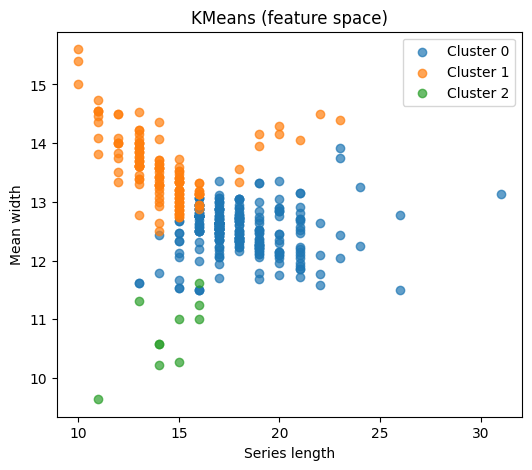

In [66]:
labels_kmeans = kmeans.labels_

features = np.array(features)

plt.figure(figsize=(6, 5))
for c in np.unique(labels_kmeans):
    idx = labels_kmeans == c
    plt.scatter(
        features[idx, -1],     # length
        features[idx, 0],      # mean
        label=f"Cluster {c}",
        alpha=0.7
    )

plt.xlabel("Series length")
plt.ylabel("Mean width")
plt.title("KMeans (feature space)")
plt.legend()
plt.show()

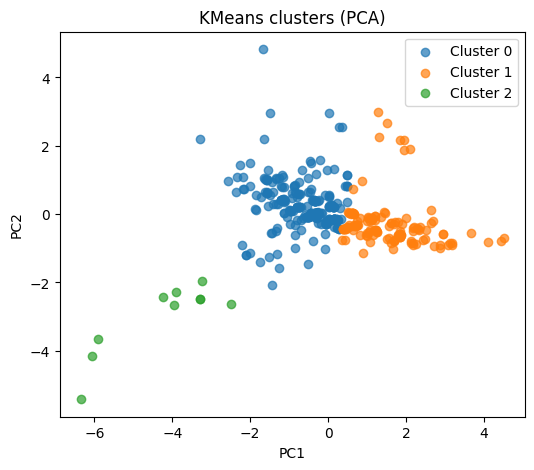

In [67]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(features)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
for c in np.unique(labels_kmeans):
    idx = labels_kmeans == c
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters (PCA)")
plt.legend()
plt.show()

C:\Users\dmitr\AppData\Local\Temp\ipykernel_23720\1429122847.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(n, len(x)), random_state=random_state))


C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj5650001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj3140001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj690001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj3100001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj3460001_stainDAPI.tif


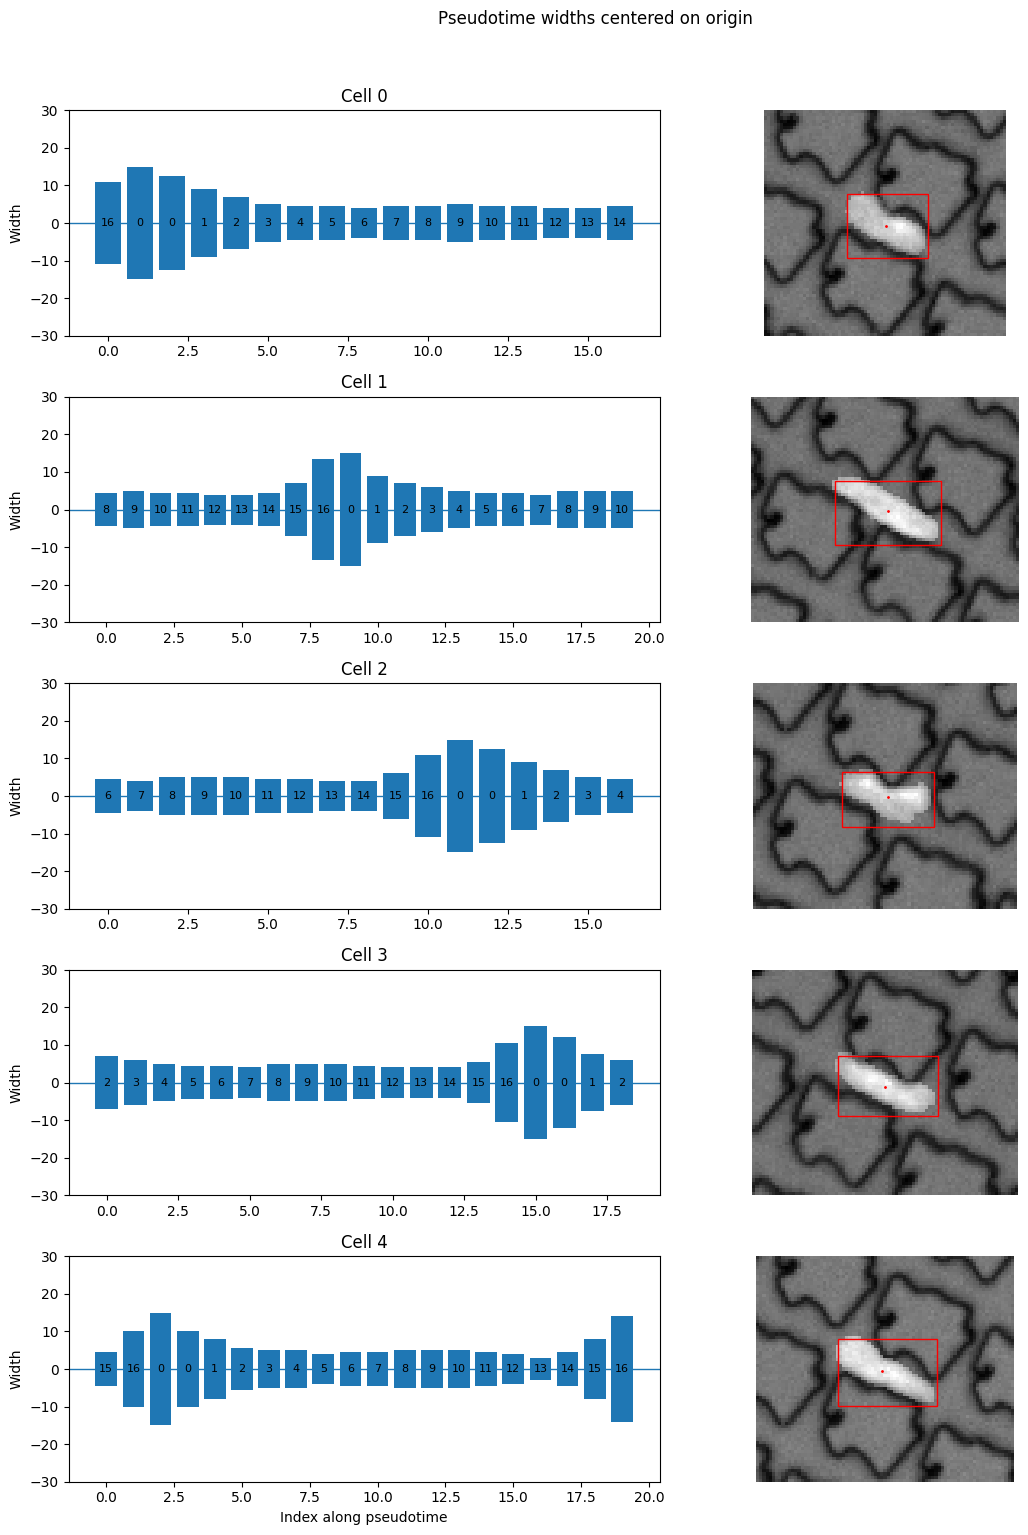

C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj2880001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj6870001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj3620001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj4340001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj2720001_stainDAPI.tif


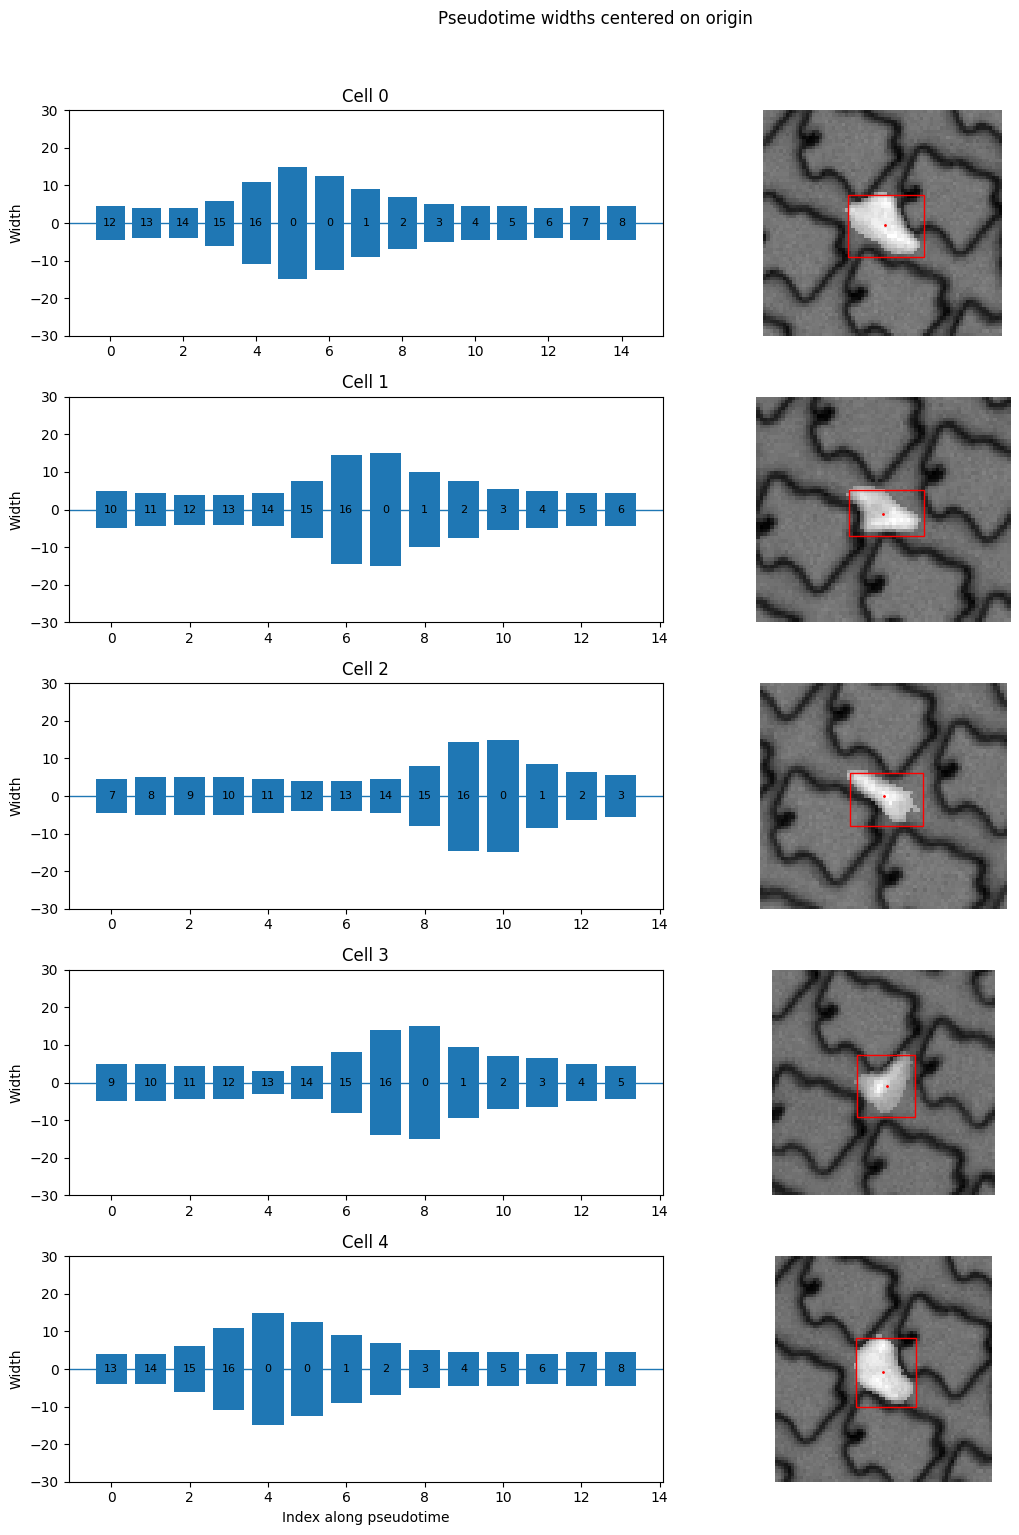

C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj1340001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj5960001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj5270001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj6490001_stainDAPI.tif
C:\Users\dmitr\Documents\Projects Coding\Nikita PhD\Chip_1462_1_real\separated dapi\obj160001_stainDAPI.tif


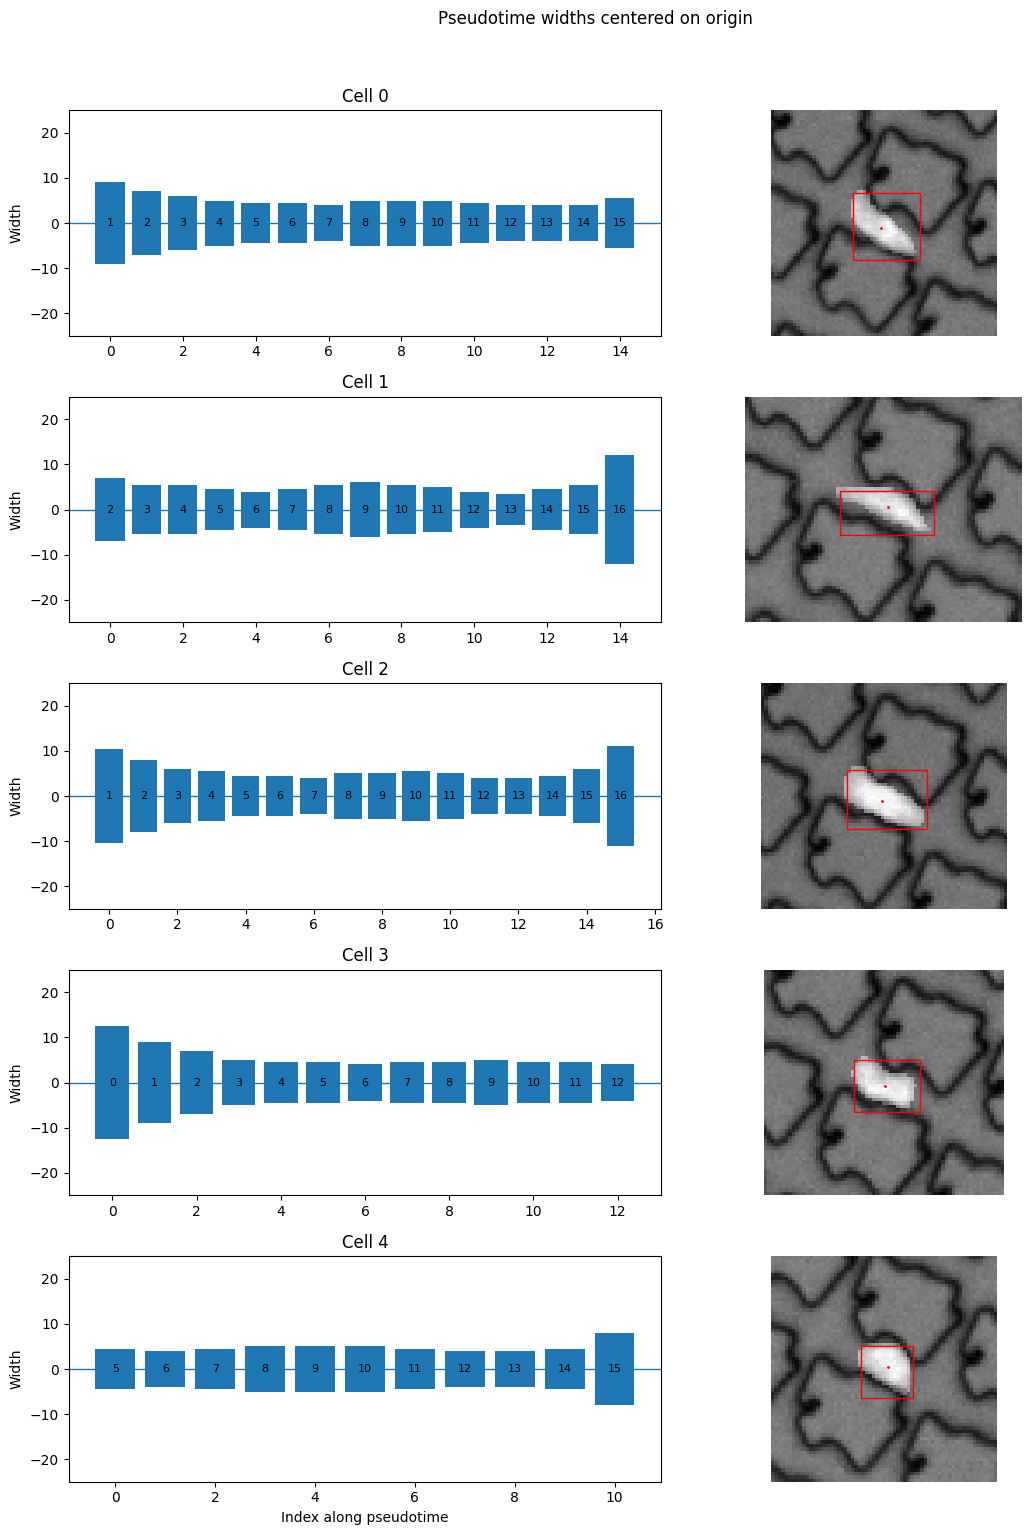

In [68]:
SD_clean['cluster_kmeans'] = labels_kmeans

df_kmeans_samples = sample_rows_per_cluster(
    SD_clean,
    cluster_col='cluster_kmeans',
    n=5
)

df_kmeans_samples

plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 0'), num_cells=5)
plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 1'), num_cells=5)
plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 2'), num_cells=5)

<Axes: xlabel='cluster_kmeans'>

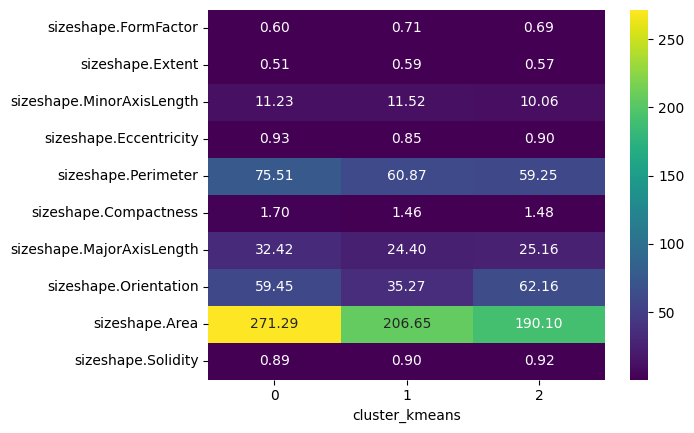

In [69]:
import seaborn as sns

feats = ['AreaShape_FormFactor', 'AreaShape_Extent','AreaShape_MinorAxisLength',
         'AreaShape_Eccentricity',  'AreaShape_Perimeter', 'AreaShape_Compactness', 
         'AreaShape_MajorAxisLength', 'AreaShape_Orientation',
         'AreaShape_Area','AreaShape_Solidity',
        ]

def name_in_df(feat):
    return  'sizeshape.' + feat.split('_')[1]

feats_CPmeasure = []
for feat in feats:
    col = name_in_df(feat)
    if col in SD_clean.columns:
        feats_CPmeasure.append(col)
    else:
        print(f"Feature {name_in_df(feat)} not found in dataframe")


SD_clean[feats_CPmeasure + ['cluster_kmeans']].groupby('cluster_kmeans').mean()

sns.heatmap( SD_clean[feats_CPmeasure + ['cluster_kmeans']] .groupby('cluster_kmeans') .mean() .T, cmap="viridis", annot=True, fmt=".2f" )

<Axes: xlabel='cluster_kmeans'>

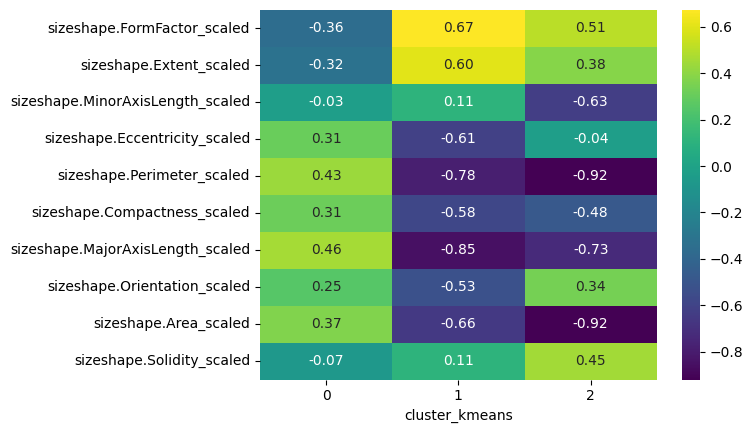

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(SD_clean[feats_CPmeasure])

feats_CPmeasure_scaled = [f + "_scaled" for f in feats_CPmeasure]

SD_clean[feats_CPmeasure_scaled] = scaled



sns.heatmap(
    SD_clean[feats_CPmeasure_scaled + ['cluster_kmeans']]
    .groupby('cluster_kmeans')
    .mean()
    .T,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

0 0.4650719874496234
1 0.38675524872710937
2 0.5195017566243225


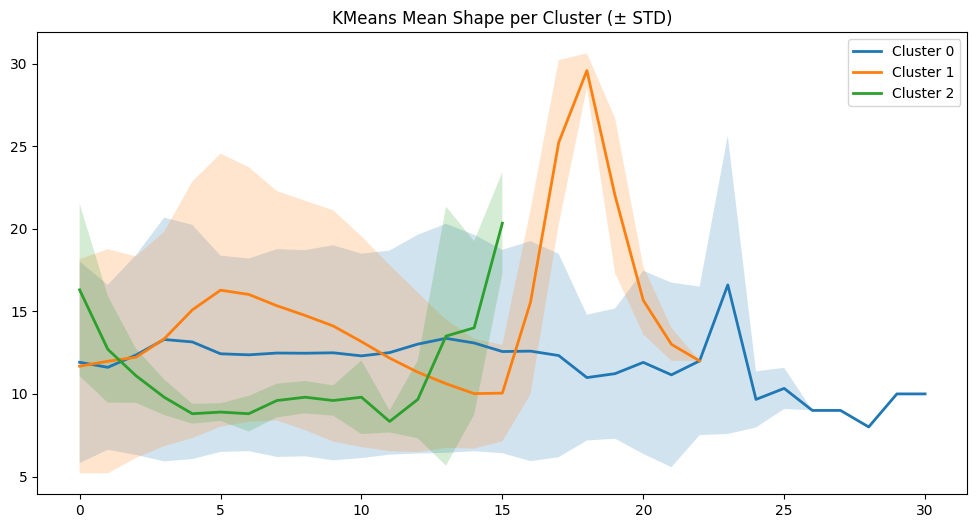

In [71]:
from sklearn.metrics import silhouette_samples

s = silhouette_samples(X_scaled, labels_kmeans)
for k in np.unique(labels_kmeans):
    print(k, s[labels_kmeans == k].mean())

X_kmeans = SD_clean["pseudotime_widths"].to_list()
labels_kmeans = SD_clean["cluster_kmeans"].values

plot_kmeans_mean_shapes(X_kmeans, labels_kmeans)  

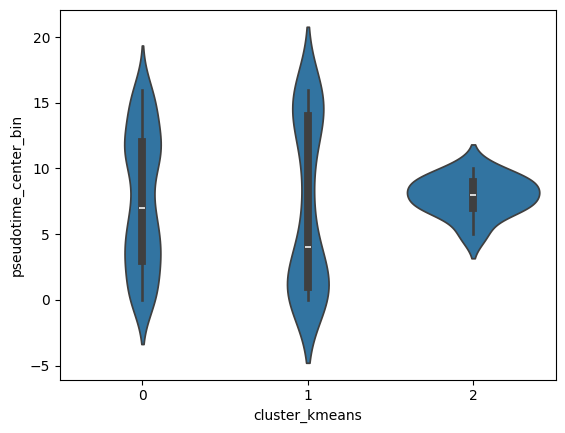

In [72]:
sns.violinplot(x='cluster_kmeans', y='pseudotime_center_bin', data=SD_clean)
plt.show()

In [73]:
mask = labels_kmeans != 2
features_no_outliers = features[mask]
X_scaled_no_Outliers = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=2, random_state=42)
labels_clean = kmeans.fit_predict(X_scaled_no_Outliers)
    
s_clean = silhouette_samples(X_scaled_no_Outliers, labels_clean)

for k in np.unique(labels_clean):
    print(k, s_clean[labels_clean == k].mean())


0 0.39631983825624645
1 0.42693393195978485


<Axes: xlabel='cluster_kmeans_no_outliers'>

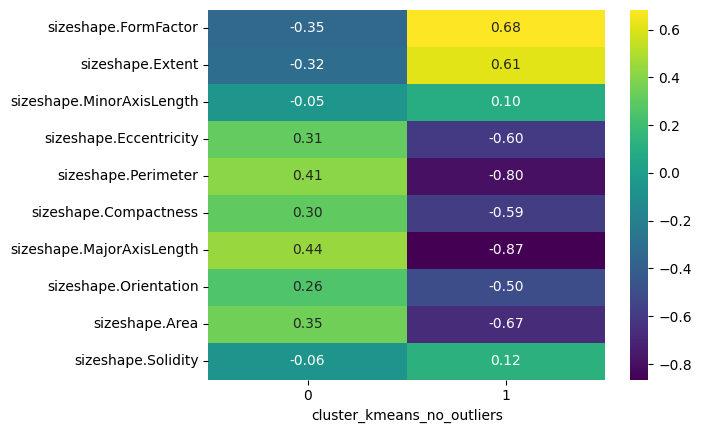

In [74]:
SD_clean_no_outliers = SD_clean.copy()
SD_clean_no_outliers['cluster_kmeans_no_outliers'] = np.where(mask, labels_clean, -1)
SD_clean_no_outliers = SD_clean_no_outliers[SD_clean_no_outliers['cluster_kmeans_no_outliers'] != -1]

scaler = StandardScaler()
scaled = scaler.fit_transform(SD_clean_no_outliers[feats_CPmeasure])

SD_clean_no_outliers[feats_CPmeasure] = scaled

sns.heatmap(
    SD_clean_no_outliers[feats_CPmeasure + ['cluster_kmeans_no_outliers']]
    .groupby('cluster_kmeans_no_outliers')
    .mean()
    .T,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

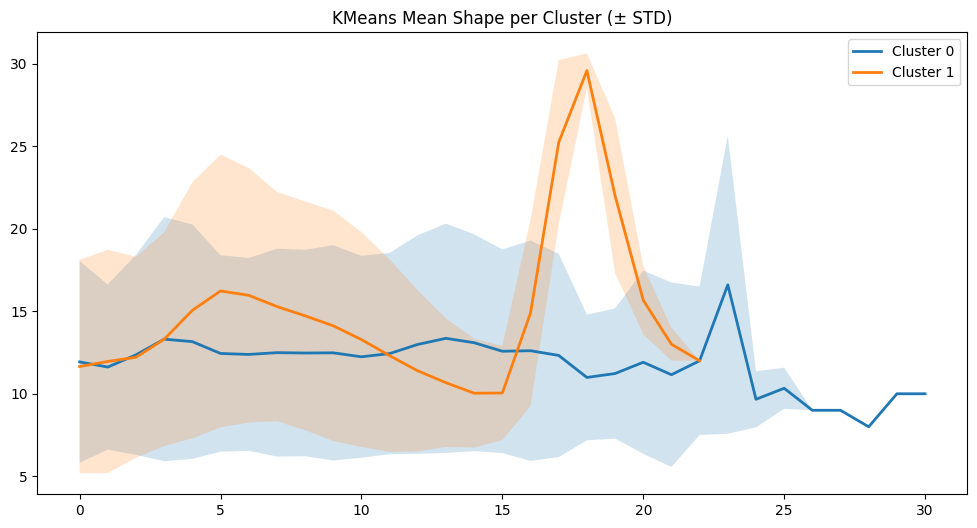

In [75]:
X_kmeans = SD_clean_no_outliers["pseudotime_widths"].to_list()
labels_kmeans = SD_clean_no_outliers["cluster_kmeans_no_outliers"].values



plot_kmeans_mean_shapes(X_kmeans, labels_kmeans)

In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# 1) Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 2) Optional: PCA to remove collinearity/noise
pca = PCA(n_components=2)  # or more components if needed
X_pca = pca.fit_transform(X_scaled)

# 3) Fit GMM
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
gmm.fit(X_pca)

# 4) Cluster labels (hard assignment)
labels_gmm = gmm.predict(X_pca)

# 5) Membership probabilities (soft assignment)
probs = gmm.predict_proba(X_pca)   # shape: (n_samples, 3)

# 6) Evaluate quality
sil = silhouette_score(X_pca, labels_gmm)
print("Silhouette GMM:", sil)

Silhouette GMM: 0.3502657695319563


In [77]:
import hdbscan

X = SD_clean['pseudotime_widths'].to_list()

X = [ts for ts in X if len(ts) >= n]  # filter out short series

X = [(ts - np.mean(ts)) / np.std(ts) for ts in X] # z-score normalization

D_dtw = cdist_dtw(X)


In [78]:
import umap
lengths = np.array([len(ts) for ts in X])
L = np.abs(lengths[:, None] - lengths[None, :])

alpha = 0.3  # controls importance of length
D = D_dtw + alpha * L

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    metric='euclidean'
)

mapper = umap.UMAP(
    metric="precomputed",
    n_neighbors=15,
    min_dist=0.025,
    random_state=42
)

X_umap = mapper.fit_transform(D_dtw)

labels_hdb = clusterer.fit_predict(X_umap)  # -1 = noise

unique, counts = np.unique(labels_hdb, return_counts=True)
print(dict(zip(unique, counts)))

c:\Users\dmitr\Documents\Projects Coding\Nikita PhD\morphology_pipeline\.venv\lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\dmitr\Documents\Projects Coding\Nikita PhD\morphology_pipeline\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{np.int64(-1): np.int64(17), np.int64(0): np.int64(29), np.int64(1): np.int64(127), np.int64(2): np.int64(32), np.int64(3): np.int64(18), np.int64(4): np.int64(102), np.int64(5): np.int64(33), np.int64(6): np.int64(56)}


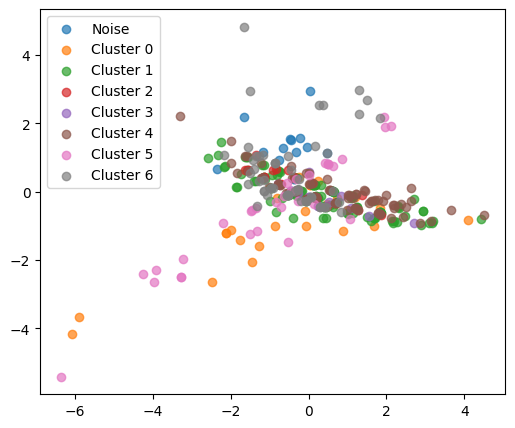

In [79]:
plt.figure(figsize=(6,5))
for c in np.unique(labels_hdb):
    idx = labels_hdb == c
    label = "Noise" if c == -1 else f"Cluster {c}"
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.7)
plt.legend()
plt.show()

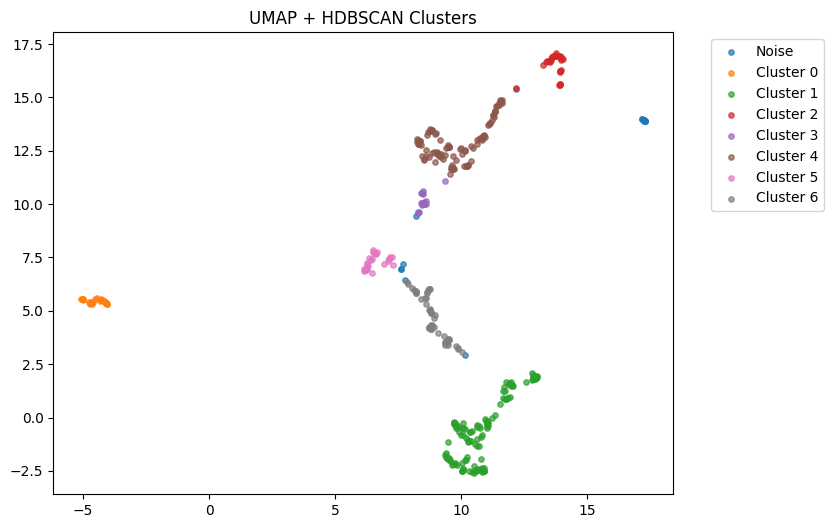

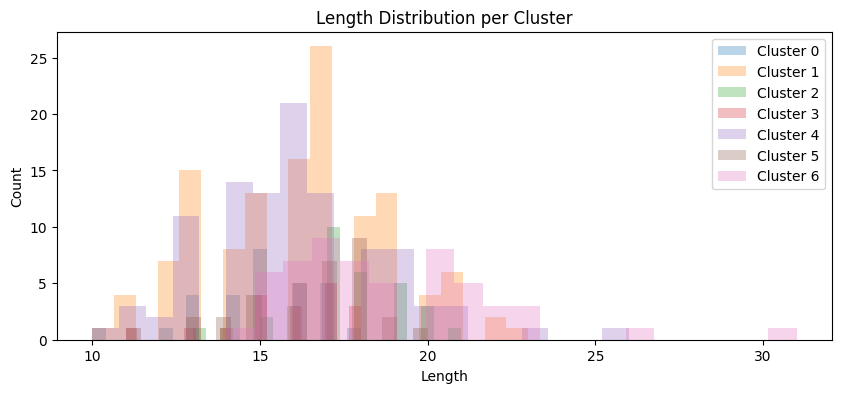

In [80]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
unique_labels = np.unique(labels_hdb)

for lab in unique_labels:
    idx = labels_hdb == lab
    label = "Noise" if lab == -1 else f"Cluster {lab}"
    plt.scatter(X_umap[idx, 0], X_umap[idx, 1], s=15, alpha=0.7, label=label)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("UMAP + HDBSCAN Clusters")
plt.show()

def plot_length_distribution(X, labels):
    lengths = np.array([len(ts) for ts in X])

    plt.figure(figsize=(10,4))
    for lab in sorted(set(labels)):
        if lab == -1:
            continue
        idx = labels == lab
        plt.hist(lengths[idx], bins=20, alpha=0.3, label=f"Cluster {lab}")

    plt.legend()
    plt.title("Length Distribution per Cluster")
    plt.xlabel("Length")
    plt.ylabel("Count")
    plt.show()

plot_length_distribution(X, labels_hdb)

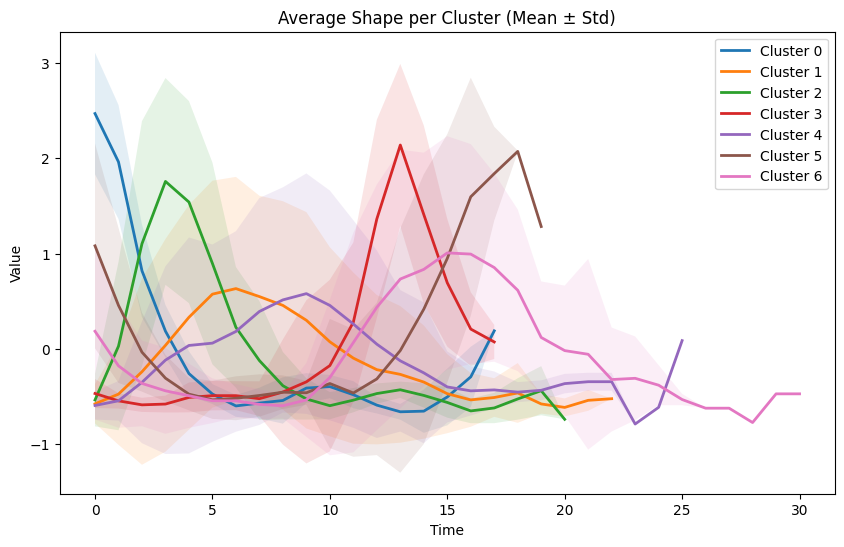

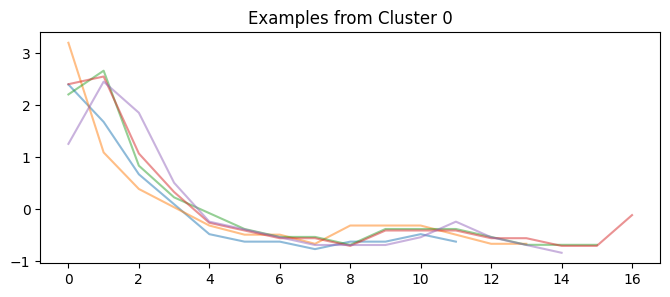

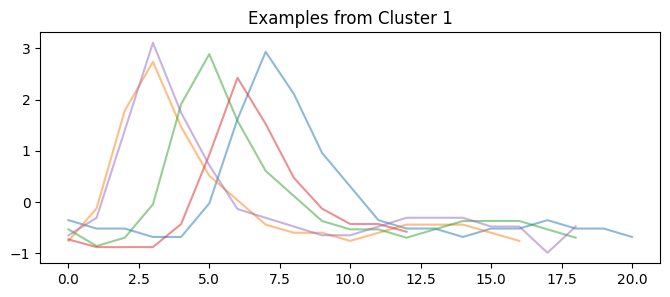

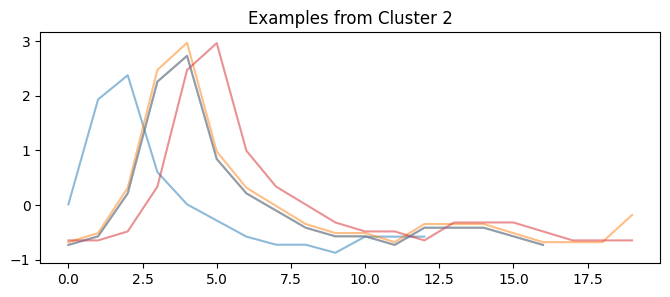

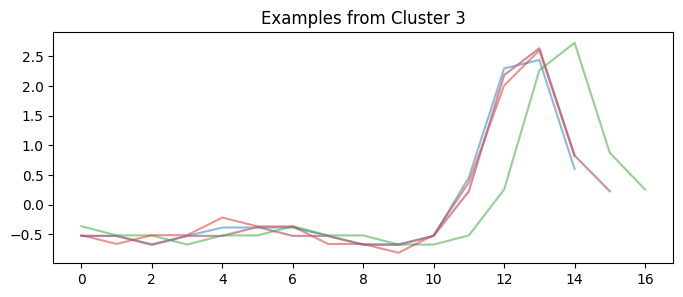

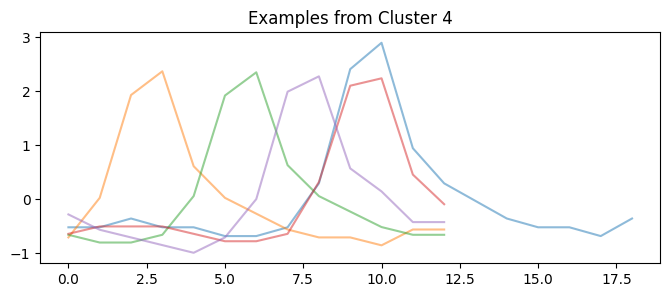

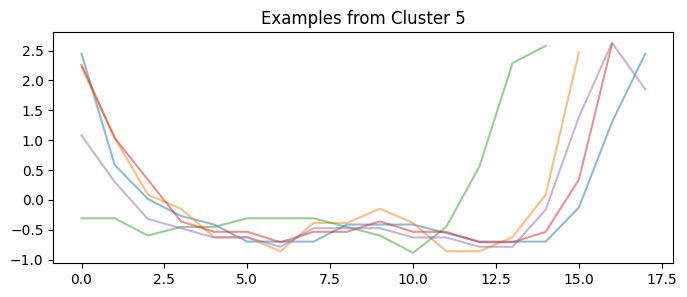

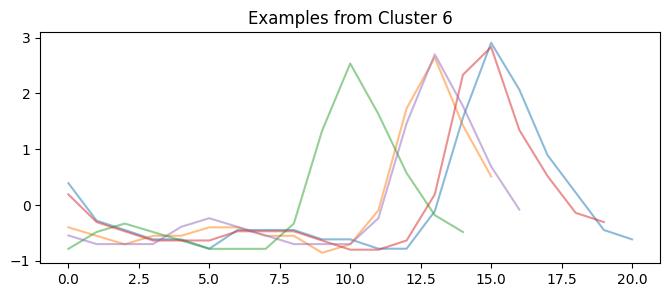

In [81]:
plt.figure(figsize=(10, 6))

for lab in np.unique(labels_hdb):
    if lab == -1:
        continue

    idx = labels_hdb == lab
    cluster_ts = [np.asarray(X[i], dtype=float) for i in np.where(idx)[0]]

    # Pad all sequences to the max length
    max_len = max(len(ts) for ts in cluster_ts)
    aligned = [
        np.pad(ts, (0, max_len - len(ts)), 'constant', constant_values=np.nan)
        for ts in cluster_ts
    ]
    aligned = np.vstack(aligned)

    # Mean and STD
    mean_ts = np.nanmean(aligned, axis=0)
    std_ts  = np.nanstd(aligned, axis=0)

    t = np.arange(max_len)

    # Plot mean
    plt.plot(t, mean_ts, label=f"Cluster {lab}", linewidth=2)

    # Plot STD as shaded area
    plt.fill_between(t, mean_ts - std_ts, mean_ts + std_ts, alpha=0.12)

plt.legend()
plt.title("Average Shape per Cluster (Mean ± Std)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

import random

for lab in np.unique(labels_hdb):
    if lab == -1:
        continue
    
    idx = np.where(labels_hdb == lab)[0]
    sample_idxs = random.sample(list(idx), min(5, len(idx)))

    plt.figure(figsize=(8, 3))
    for i in sample_idxs:
        plt.plot(X[i], alpha=0.5)
    plt.title(f"Examples from Cluster {lab}")
    plt.show()

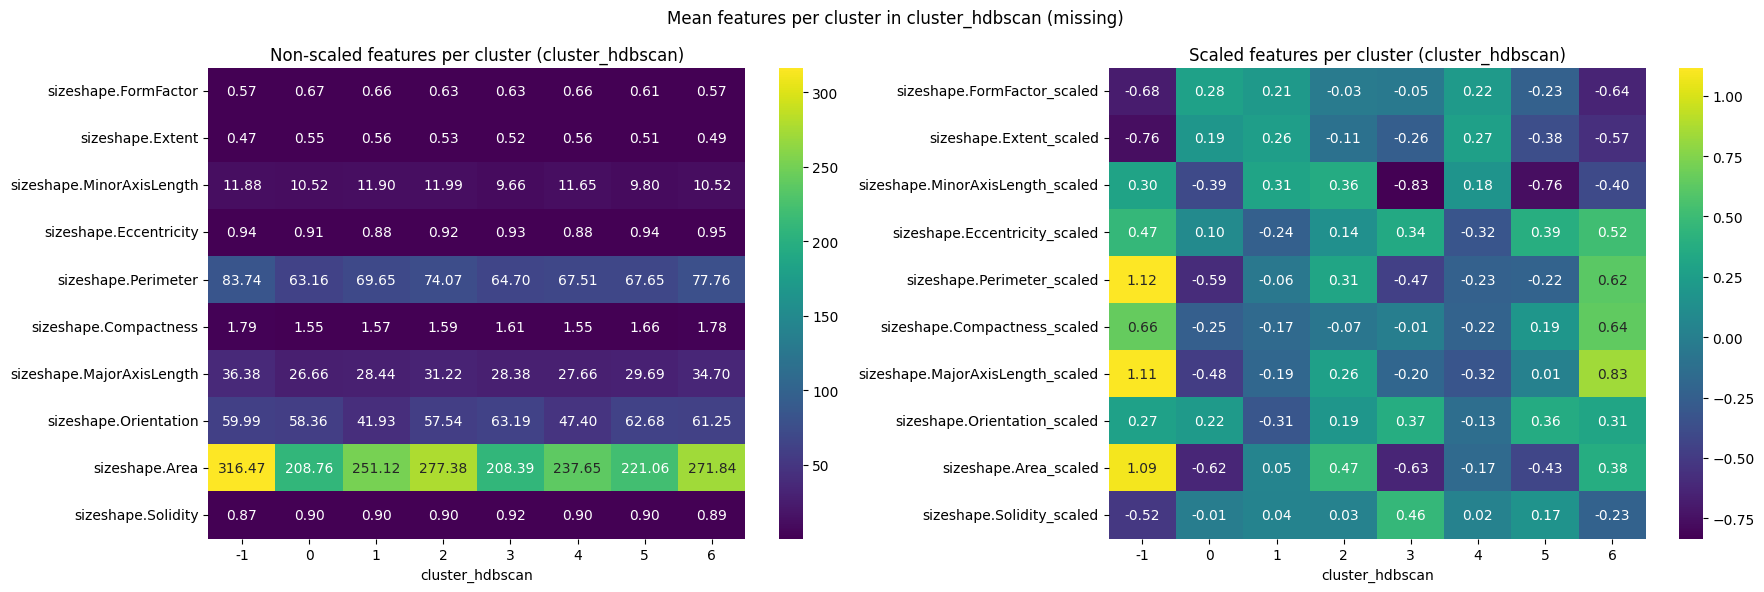

In [82]:
SD_clean["cluster_hdbscan"] = labels_hdb

def plot_metadata_heatmap(
    df,
    scaled_features,
    non_scaled_features,
    cluster_col,
    title="missing"
):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

    # --- Non-scaled features heatmap ---
    non_scaled_data = (
        df[non_scaled_features + [cluster_col]]
        .groupby(cluster_col)
        .mean()
        .T
    )

    sns.heatmap(
        non_scaled_data,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        ax=axes[0]
    )

    axes[0].set_title(f"Non-scaled features per cluster ({cluster_col})")

    # --- Scaled features heatmap ---
    scaled_data = (
        df[scaled_features + [cluster_col]]
        .groupby(cluster_col)
        .mean()
        .T
    )

    sns.heatmap(
        scaled_data,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        ax=axes[1]
    )

    axes[1].set_title(f"Scaled features per cluster ({cluster_col})")

    fig.suptitle(f"Mean features per cluster in {cluster_col} ({title})")

    plt.tight_layout()
    plt.show()



plot_metadata_heatmap(
    SD_clean,
    feats_CPmeasure_scaled,
    feats_CPmeasure,
    "cluster_hdbscan"
)

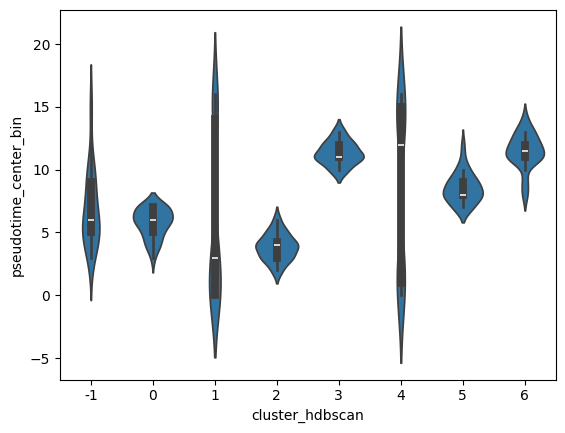

In [83]:
sns.violinplot(x='cluster_hdbscan', y='pseudotime_center_bin', data=SD_clean)
plt.show()

In [84]:
import os
import shutil
from tqdm import tqdm

def export_dapi_by_cluster(df, cluster_col, dapi_col, out_dir):
    """
    df          : pandas DataFrame
    cluster_col : column name containing cluster labels (e.g. 'cluster_hdbscan')
    dapi_col    : column name containing the DAPI file paths (e.g. 'path_dapi')
    out_dir     : output directory where cluster folders will be created
    """

    os.makedirs(out_dir, exist_ok=True)

    for cluster in sorted(df[cluster_col].unique()):
        cluster_path = os.path.join(out_dir, f"cluster_{cluster}")
        os.makedirs(cluster_path, exist_ok=True)

        sub_df = df[df[cluster_col] == cluster]

        print(f"Exporting {len(sub_df)} DAPI images for cluster {cluster}...")

        for _, row in tqdm(sub_df.iterrows(), total=len(sub_df)):
            src = row[dapi_col]
            
            if not os.path.exists(src):
                print(f"WARNING: File not found: {src}")
                continue

            # keep original filename
            filename = os.path.basename(src)
            dst = os.path.join(cluster_path, filename)

            shutil.copy(src, dst)

    print("Done.")

export_dapi_by_cluster(
    df=SD_clean,                # your dataframe
    cluster_col="cluster_hdbscan",   # or cluster_kmeans_no_outliers
    dapi_col="path_dapi",
    out_dir="sorted_dapi_images_UMAP+HDBSCAN_1462"     # will be created automatically
)

Exporting 17 DAPI images for cluster -1...


100%|██████████| 17/17 [00:00<00:00, 943.58it/s]


Exporting 29 DAPI images for cluster 0...


100%|██████████| 29/29 [00:00<00:00, 999.08it/s]


Exporting 127 DAPI images for cluster 1...


100%|██████████| 127/127 [00:00<00:00, 999.09it/s] 


Exporting 32 DAPI images for cluster 2...


100%|██████████| 32/32 [00:00<00:00, 913.45it/s]


Exporting 18 DAPI images for cluster 3...


100%|██████████| 18/18 [00:00<00:00, 946.49it/s]


Exporting 102 DAPI images for cluster 4...


100%|██████████| 102/102 [00:00<00:00, 999.09it/s] 


Exporting 33 DAPI images for cluster 5...


100%|██████████| 33/33 [00:00<00:00, 969.71it/s]


Exporting 56 DAPI images for cluster 6...


100%|██████████| 56/56 [00:00<00:00, 981.56it/s]

Done.


In [85]:

colums = ['ObjectNumber', 'Metadata_ObjNumber'] + feats

cluster_map = SD_clean[["Metadata_ObjNumber", "ObjectNumber", "cluster_hdbscan"]]

def add_cluster_to_cp(cp_df, cluster_map):
    return cp_df.merge(
        cluster_map,
        on=["Metadata_ObjNumber", "ObjectNumber"],
        how="inner"
    )  # avoid duplicate

df_identifyPrimaryObjects = add_cluster_to_cp(df_identifyPrimaryObjects, cluster_map)
df_Phalloidin_segmented = add_cluster_to_cp(df_Phalloidin_segmented, cluster_map)
df_YAP_segmented = add_cluster_to_cp(df_YAP_segmented, cluster_map)

df_identifyPrimaryObjects["cluster_hdbscan"]



0      4
1      6
2      1
3      1
4      4
      ..
409    4
410    0
411    1
412    3
413    1
Name: cluster_hdbscan, Length: 414, dtype: int64

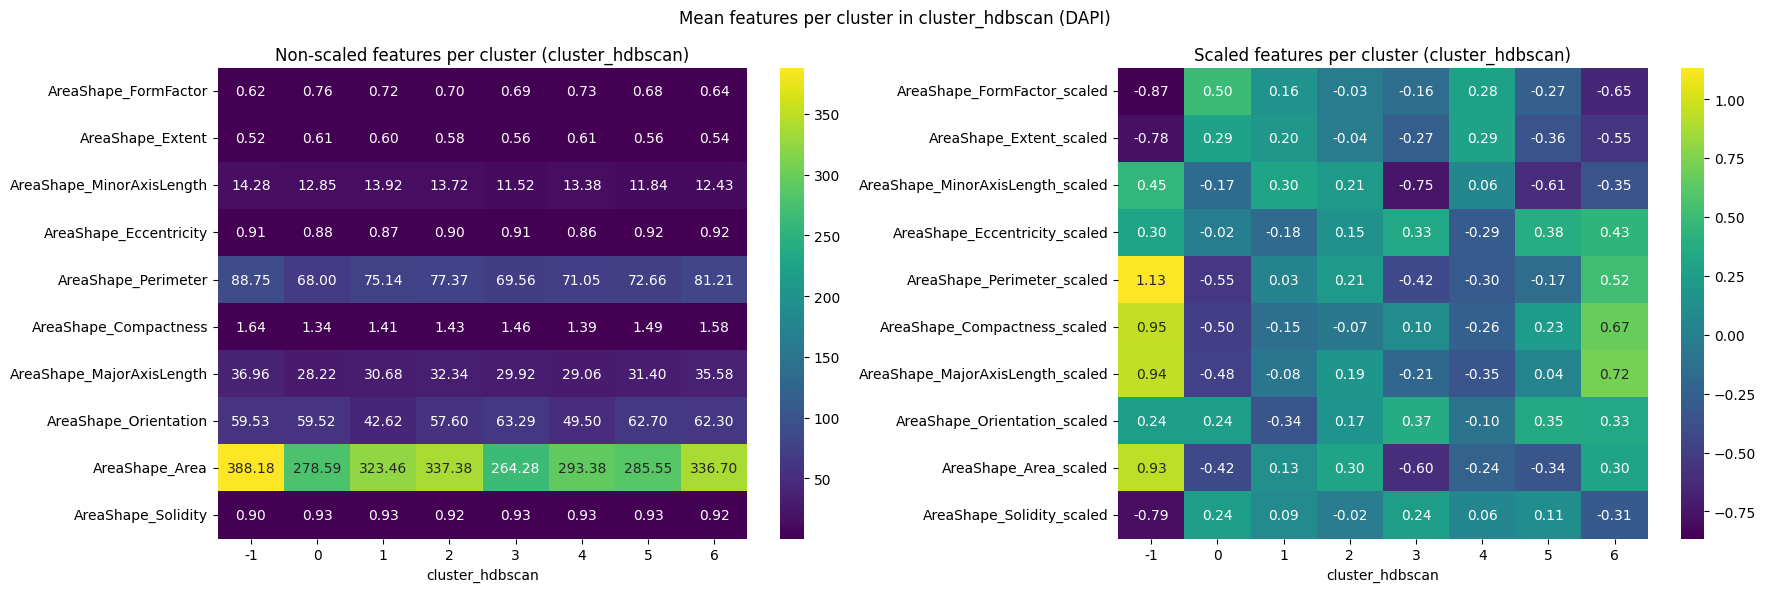

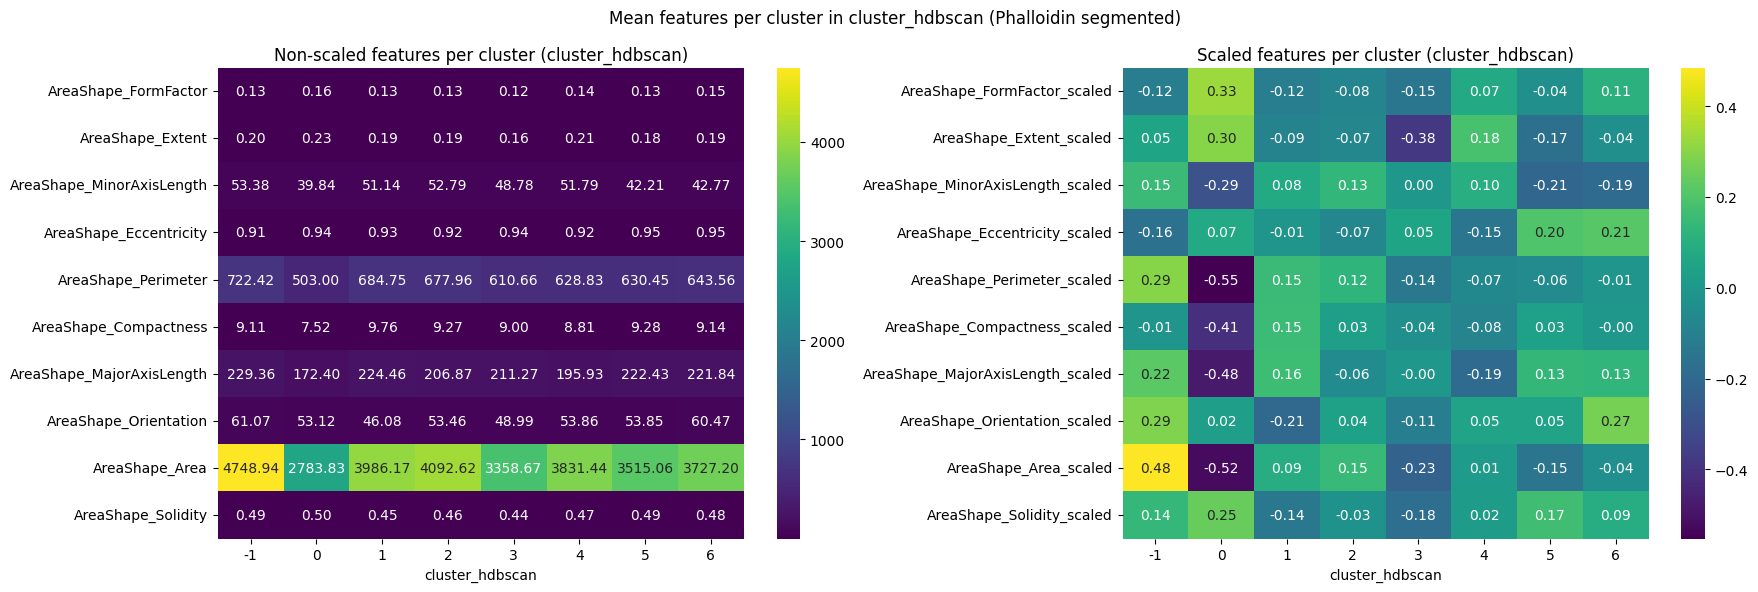

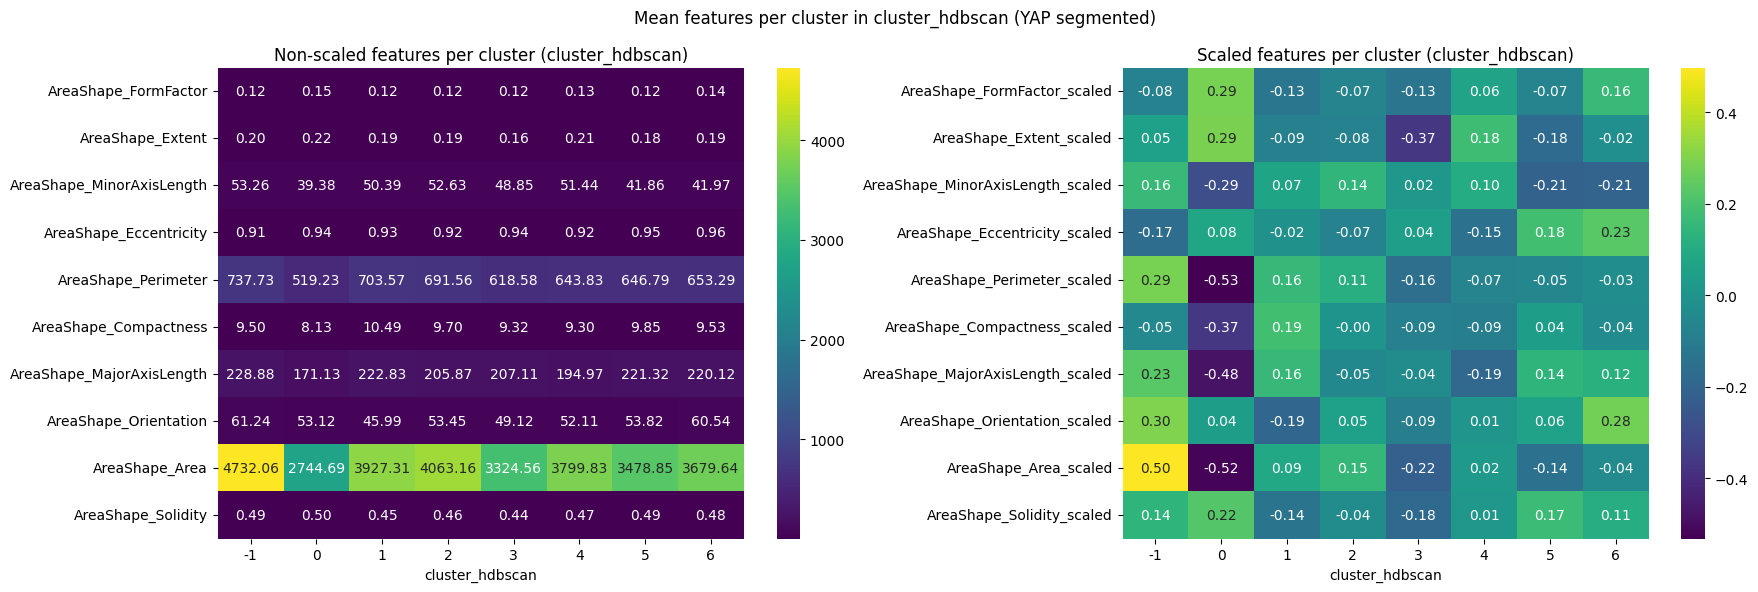

DAPI cluster counts:
cluster_hdbscan
 1    127
 4    102
 6     56
 5     33
 2     32
 0     29
 3     18
-1     17
Name: count, dtype: int64

Phalloidin segmented cluster counts:
cluster_hdbscan
 1    127
 4    102
 6     56
 5     33
 2     32
 0     29
 3     18
-1     17
Name: count, dtype: int64

YAP segmented cluster counts:
cluster_hdbscan
 1    127
 4    102
 6     56
 5     33
 2     32
 0     29
 3     18
-1     17
Name: count, dtype: int64


In [86]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df_identifyPrimaryObjects[feats])

feats_scaled = [f + "_scaled" for f in feats]   

df_identifyPrimaryObjects[feats_scaled] = scaled

plot_metadata_heatmap(
    df_identifyPrimaryObjects,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_hdbscan",
    title="DAPI"
)

scaler = StandardScaler()
scaled = scaler.fit_transform(df_Phalloidin_segmented[feats])

df_Phalloidin_segmented[feats_scaled] = scaled

plot_metadata_heatmap(
    df_Phalloidin_segmented,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_hdbscan",
    title="Phalloidin segmented"
)

scaler = StandardScaler()
scaled = scaler.fit_transform(df_YAP_segmented[feats])

df_YAP_segmented[feats_scaled] = scaled

plot_metadata_heatmap(
    df_YAP_segmented,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_hdbscan",
    title="YAP segmented"
)

#counts per cluster
print("DAPI cluster counts:")
print(df_identifyPrimaryObjects["cluster_hdbscan"].value_counts())
print("\nPhalloidin segmented cluster counts:")
print(df_Phalloidin_segmented["cluster_hdbscan"].value_counts())
print("\nYAP segmented cluster counts:")
print(df_YAP_segmented["cluster_hdbscan"].value_counts())

In [87]:


def export_dapi_by_cluster(df, cluster_col, imgID_col, out_dir, Actin_dir, YAP_dir):
    """
    df          : pandas DataFrame
    cluster_col : column name containing cluster labels (e.g. 'cluster_hdbscan')
    imgID_col   : column name containing the image IDs (e.g. 'imgID')
    out_dir     : output directory where cluster folders will be created
    Actin_dir   : directory containing Actin images
    YAP_dir     : directory containing YAP images
    """

    os.makedirs(out_dir, exist_ok=True)

    for cluster in sorted(df[cluster_col].unique()):
        cluster_path = os.path.join(out_dir, f"cluster_{cluster}")
        os.makedirs(cluster_path, exist_ok=True)

        sub_df = df[df[cluster_col] == cluster]

        print(f"Exporting {len(sub_df)} DAPI images for cluster {cluster}...")

        for _, row in tqdm(sub_df.iterrows(), total=len(sub_df)):
            img_id = row[imgID_col]
            img_prefix = f"obj{img_id:04d}"

            # --- find matching Actin file ---
            actin_matches = [
                f for f in os.listdir(Actin_dir)
                if f.startswith(img_prefix)
            ]

            # --- find matching YAP file ---
            yap_matches = [
                f for f in os.listdir(YAP_dir)
                if f.startswith(img_prefix)
            ]

            # copy Actin files
            for f in actin_matches:
                src = os.path.join(Actin_dir, f)
                dst = os.path.join(cluster_path, f)
                shutil.copy(src, dst)

            # copy YAP files
            for f in yap_matches:
                src = os.path.join(YAP_dir, f)
                dst = os.path.join(cluster_path, f)
                shutil.copy(src, dst)


            shutil.copy(src, dst)

    print("Done.")


export_dapi_by_cluster(
    df=df_identifyPrimaryObjects,                # your dataframe
    cluster_col="cluster_hdbscan",   # or cluster_kmeans_no_outliers
    imgID_col="Metadata_ObjNumber",
    out_dir="sorted_YAP+ACTIN_by_cluster_UMAP+HDBSCAN_1462",     # will be created automatically
    Actin_dir="../1462_1/Actin_DAPI_overlays",
    YAP_dir="../1462_1/YAP_DAPI_overlays"
)



     

Exporting 17 DAPI images for cluster -1...


100%|██████████| 17/17 [00:00<00:00, 212.31it/s]


Exporting 29 DAPI images for cluster 0...


100%|██████████| 29/29 [00:00<00:00, 268.28it/s]


Exporting 127 DAPI images for cluster 1...


100%|██████████| 127/127 [00:00<00:00, 279.48it/s]


Exporting 32 DAPI images for cluster 2...


100%|██████████| 32/32 [00:00<00:00, 282.93it/s]


Exporting 18 DAPI images for cluster 3...


100%|██████████| 18/18 [00:00<00:00, 281.00it/s]


Exporting 102 DAPI images for cluster 4...


100%|██████████| 102/102 [00:00<00:00, 272.48it/s]


Exporting 33 DAPI images for cluster 5...


100%|██████████| 33/33 [00:00<00:00, 242.43it/s]


Exporting 56 DAPI images for cluster 6...


100%|██████████| 56/56 [00:00<00:00, 259.02it/s]

Done.


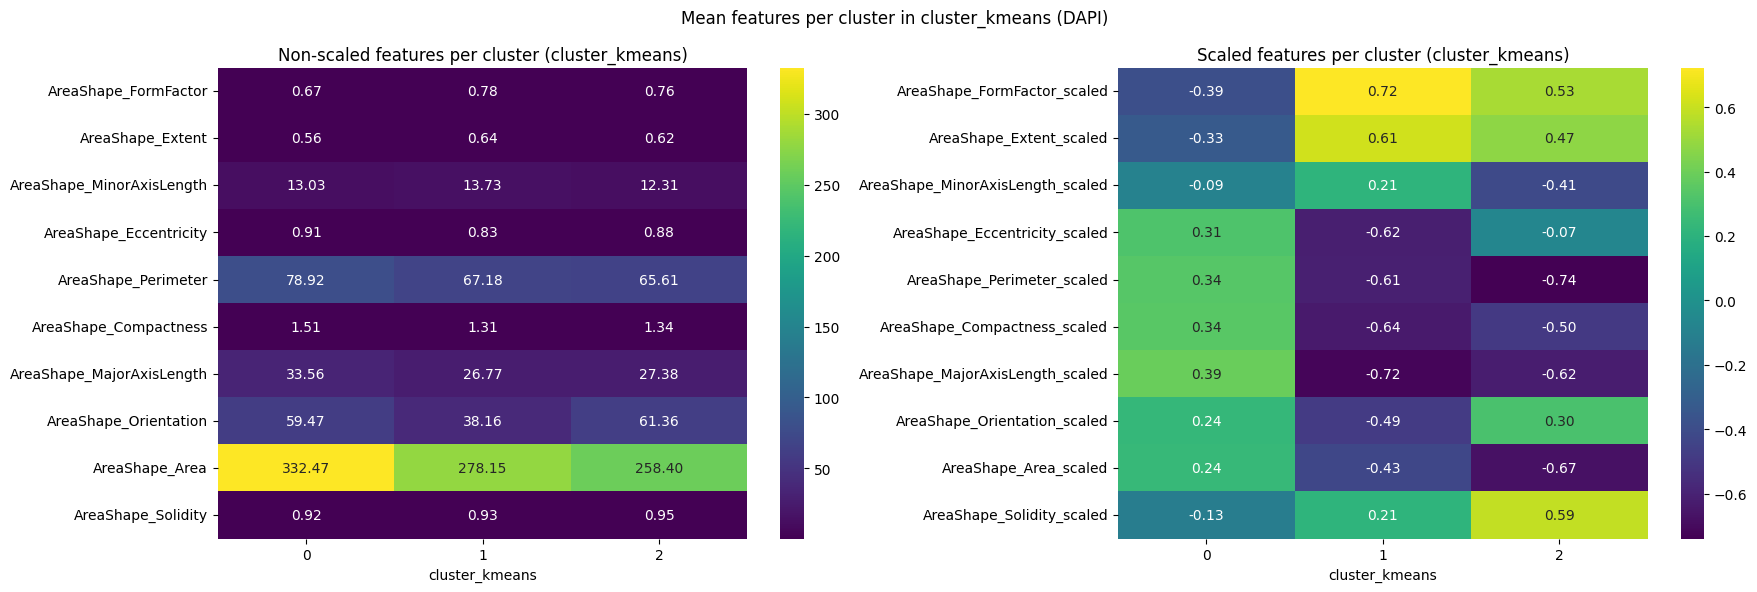

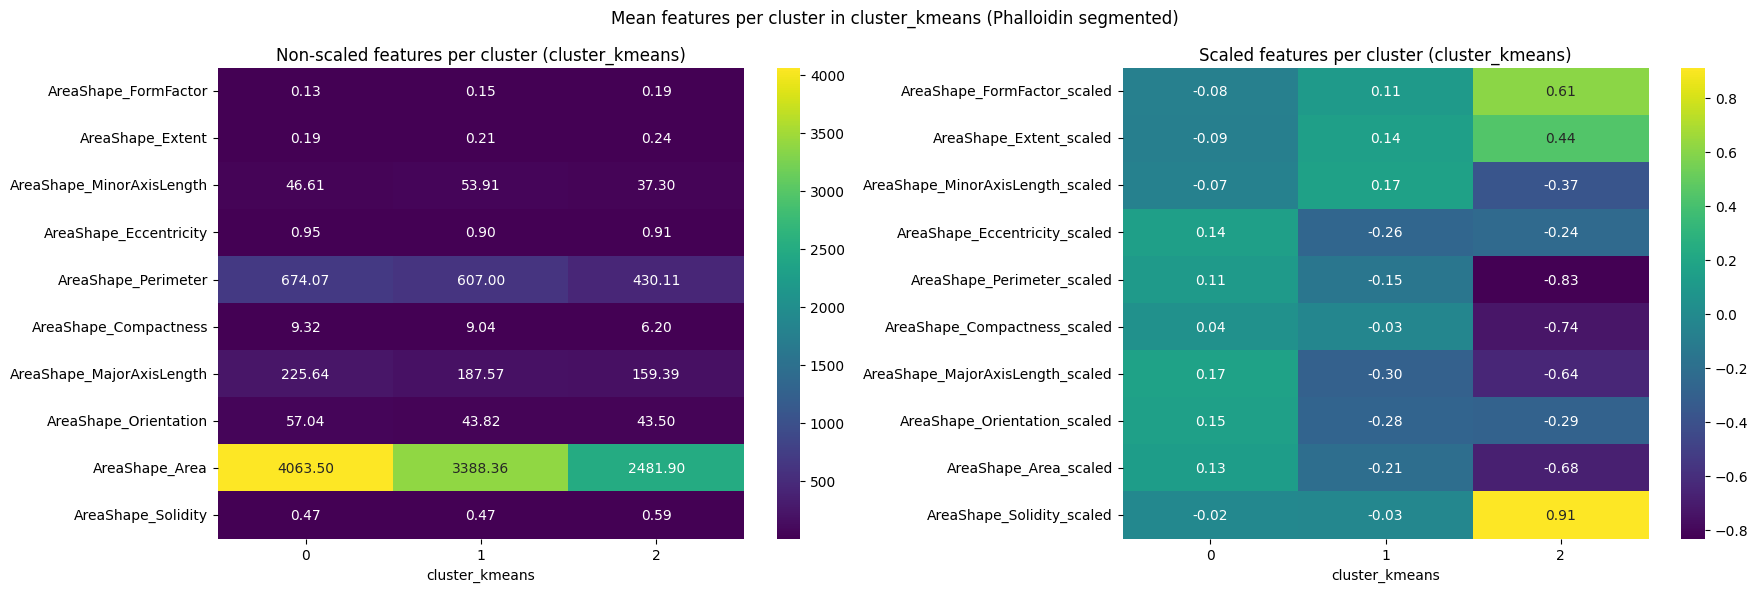

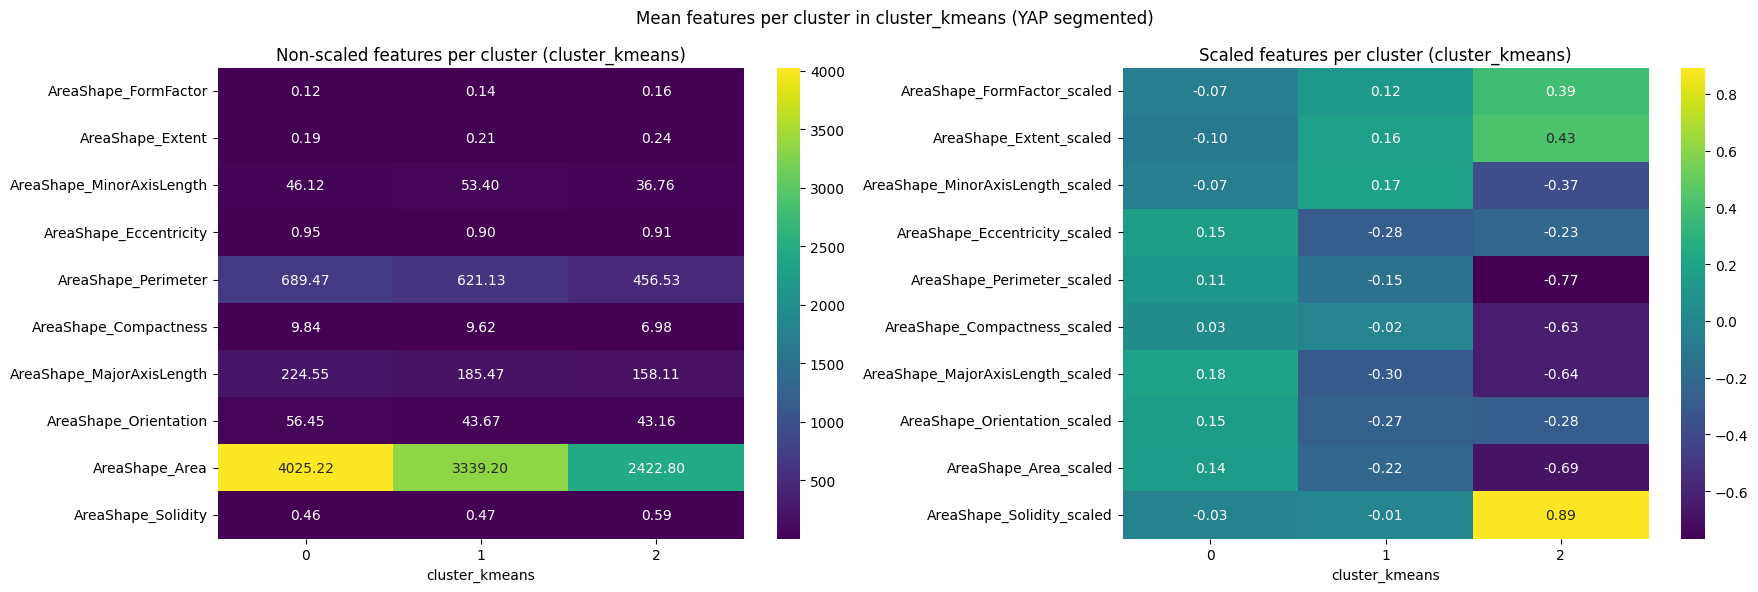

In [89]:
cluster_map_kmeans = SD_clean[["Metadata_ObjNumber", "ObjectNumber", "cluster_kmeans"]]

df_identifyPrimaryObjects = add_cluster_to_cp(df_identifyPrimaryObjects, cluster_map_kmeans)
df_Phalloidin_segmented = add_cluster_to_cp(df_Phalloidin_segmented, cluster_map_kmeans)
df_YAP_segmented = add_cluster_to_cp(df_YAP_segmented, cluster_map_kmeans)

plot_metadata_heatmap(
    df_identifyPrimaryObjects,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_kmeans",
    title="DAPI"
)

plot_metadata_heatmap(
    df_Phalloidin_segmented,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_kmeans",
    title="Phalloidin segmented"
)

plot_metadata_heatmap(
    df_YAP_segmented,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_kmeans",
    title="YAP segmented"
)



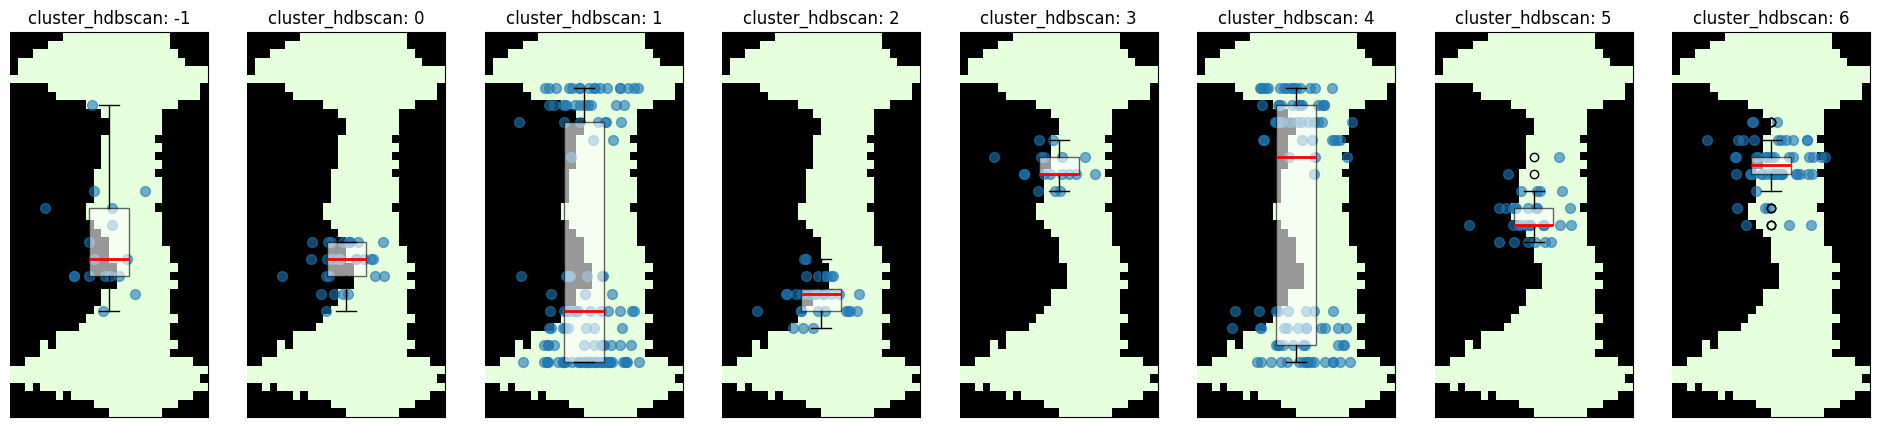

In [90]:
def plots_on_background(
    img_path,
    df,
    value_col,
    cluster_col,
    m=2,
    rotate=True,
    bw_method=0.3
):
    


    # --- load image ---
    img = plt.imread(img_path)

    img = np.rot90(img)

    if img.shape[2] == 3:
        alpha = np.ones((img.shape[0], img.shape[1], 1))
        img = np.concatenate([img, alpha], axis=2)
    
    mask = (img[:, :, :3] > 0.98).all(axis=2)

    img[mask] = img[mask] = [230/255, 255/255, 221/255, 1]    

    H, W = img.shape[:2]
    y_max = H / m

    buffer_px = H * (20 / 140)

    buffer_ratio = 20 / 140

    y_start = y_max * buffer_ratio
    y_end = y_max * (1 - buffer_ratio)

    plot_height = y_end - y_start

    clusters = sorted(df[cluster_col].dropna().unique())
    n_clusters = len(clusters)

    # create subplots (one per cluster)
    fig, axes = plt.subplots(
        1,
        n_clusters,
        figsize=(3 * n_clusters, 5),
        sharey=True
    )

    if n_clusters == 1:
        axes = [axes]

    for ax, cluster in zip(axes, clusters):

        # draw background image
        ax.imshow(
            img,
            extent=[0, W, 0, y_max],
            origin="upper",
            aspect="auto"
        )

        # extract cluster data
        data = (
            df.loc[df[cluster_col] == cluster, value_col]
            .dropna()
            .to_numpy()
        )

        y = y_start + data

        rng = np.random.default_rng(0)

        x = W/2 + rng.normal(0, W * 0.14, size=len(data))

        ax.scatter(
            x,
            y,
            s=50,
            alpha=0.6
        )

        
        ax.boxplot(
            y,
            positions=[W/2],
            widths=W * 0.2,
            vert=True,
            patch_artist=True,
            boxprops=dict(facecolor="white", alpha=0.6),
            medianprops=dict(color="red", linewidth=2),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black")
        )

        ax.set_xlim(0, W)
        ax.set_ylim(0, y_max)
        ax.set_yticks([])
        ax.set_ylabel("")
        ax.spines["left"].set_visible(False)

        ax.set_title(f"{cluster_col}: {cluster}")
        ax.set_xticks([])

    plt.show()


plots_on_background(
    img_path="res\period_corridor_7_2026-03-10_20-58-10.png",
    df=SD_clean,
    value_col="pseudotime_center_bin",
    cluster_col="cluster_hdbscan"
)

In [91]:
for c in SD_clean["cluster_hdbscan"].unique():
    d = SD_clean.loc[SD_clean["cluster_hdbscan"] == c, "pseudotime_center_bin"]
    print(c, len(d), np.std(d))

4 102 6.743081378874368
6 56 1.3887301496588271
1 127 6.478367690899913
5 33 1.1829831088450387
-1 17 2.8877500490902532
2 32 1.0340870067358936
0 29 1.1342678760964502
3 18 0.8819171036881969


In [93]:
SD_clean.to_csv("datasets/combined_clustered_data 1462.csv", index=False)